In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pingouin as pg
import seaborn as sns
from dotenv import load_dotenv

from multipred.plotting import (analyze_attention_ROI, barplot_morey,
                                plot_decoding_nvoxels)

In [2]:
load_dotenv("../../.env")
PROJECT_PATH = os.getenv("PROJECT_PATH")
DATA_PATH = f"{PROJECT_PATH}/data/derivatives/decoding_data/"
ROI = "EVC"

## Comparing decoding across ROI sizes

24 subjects in 50 voxels mask. Visual modality: t(23)=3.8526, p=0.0004. Auditory modality: t(23)=1.7065, p=0.0945
24 subjects in 100 voxels mask. Visual modality: t(23)=4.9108, p=0.0000. Auditory modality: t(23)=4.3278, p=0.0001
23 subjects in 150 voxels mask. Visual modality: t(22)=6.4608, p=0.0000. Auditory modality: t(22)=3.9624, p=0.0003
23 subjects in 200 voxels mask. Visual modality: t(22)=6.2898, p=0.0000. Auditory modality: t(22)=5.0205, p=0.0000
23 subjects in 250 voxels mask. Visual modality: t(22)=6.9007, p=0.0000. Auditory modality: t(22)=5.5404, p=0.0000
23 subjects in 300 voxels mask. Visual modality: t(22)=7.8709, p=0.0000. Auditory modality: t(22)=5.3253, p=0.0000
23 subjects in 350 voxels mask. Visual modality: t(22)=8.0259, p=0.0000. Auditory modality: t(22)=4.5688, p=0.0000
24 subjects in funcloc voxels mask. Visual modality: t(23)=6.4012, p=0.0000. Auditory modality: t(23)=5.3528, p=0.0000
25 subjects in wholeROI voxels mask. Visual modality: t(24)=5.7604, p=0.0000.

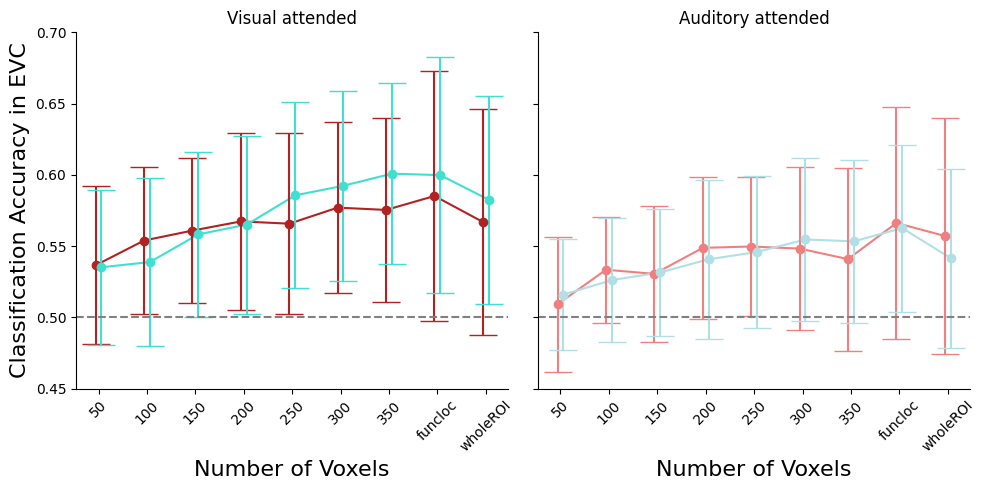

In [ ]:
n_voxels_list = [
    "50",
    "100",
    "150",
    "200",
    "250",
    "300",
    "350",
    "funcloc",
    "wholeROI",
]
df_allROIs = plot_decoding_nvoxels(DATA_PATH, n_voxels_list, ROI, "v_pred", save_fig=False)

## Analyze specific ROIs

In [67]:
ROI = "EVC"
n_voxels = "wholeROI"
df = pd.read_csv(f"{DATA_PATH}/{ROI}_{n_voxels}/balanced_group_data.csv")
df["prob_predictions"] = np.where(df["prob_0"] < 0.5, 45, 135)
df["prob_correct"] = np.where(
    df["labels"] == df["prob_predictions"], 1, 0
)  # 1 if prob prediction is correct, 0 if not


### Attention * visual prediction

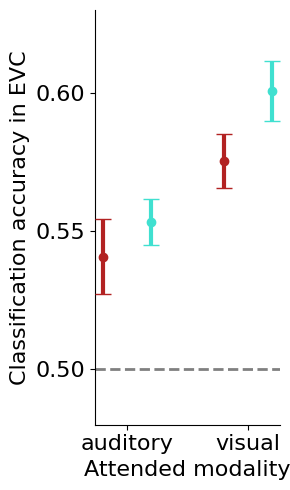

In [60]:
y = "correct"
x = "modality"
hue = "v_pred"
id = "subj"
savefig = False
errorbar_style={"capsize": 6, "elinewidth": 3, "markersize": 6}

dat = df.copy().groupby([id, x, hue], as_index=False)[y].mean()
fig, ax = plt.subplots(figsize=(3, 5))
barplot_morey(dat, x, y, hue, "visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], False, False, False, ax, legend=False, errorbar_style=errorbar_style, fontsize=16)
sns.despine()
plt.xticks([0, 1], ["auditory", "visual"])
plt.ylabel(f"Classification accuracy in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0.48, 0.63)
plt.yticks([0.5, 0.55, 0.6])
plt.axhline(0.5, color="grey", linestyle="--", linewidth=2)
plt.tight_layout()
if savefig:
    plt.savefig(f"figures/MVPA/attention_pred_{ROI}.svg", dpi=300)
plt.show()

In [50]:
df[y].mean()

np.float64(0.5653079710144927)

In [51]:
df.groupby(["modality"])[y].mean()

modality
auditory    0.547876
visual      0.582740
Name: prob_correct, dtype: float64

In [52]:
pg.rm_anova(dv=y, within=[x, hue], subject=id, data=dat.copy())

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,modality,0.027957,1,22,0.027957,8.634578,0.007602,0.007602,0.062140,1.0
1,v_pred,0.007616,1,22,0.007616,4.178166,0.053100,0.053100,0.017731,1.0
2,modality * v_pred,0.000035,1,22,0.000035,0.023158,0.880433,0.880433,0.000083,1.0


In [53]:
pg.pairwise_tests(dv=y, within=[x, hue], subject=id, data=dat, padjust="fdr_bh")

,Contrast,modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,modality,-,auditory,visual,True,True,-2.938465,22.0,two-sided,0.007602,NaN,NaN,6.18,-0.544372
1,v_pred,-,0,1,True,True,-2.044056,22.0,two-sided,0.053100,NaN,NaN,1.26,-0.297737
2,modality * v_pred,auditory,0,1,True,True,-1.275541,22.0,two-sided,0.215423,0.215423,fdr_bh,0.448,-0.250792
3,modality * v_pred,visual,0,1,True,True,-1.830495,22.0,two-sided,0.080757,0.161515,fdr_bh,0.911,-0.265612


### Multimodal analyses

c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
c:\Users\marcs\Documents\multipred-fmri\.venv\Lib\site-packages\pingouin\distribution.py:508: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  .diff(axis=1)
C:\Users\marcs\Documents\multipred-fmri\multipred\plotting.py:92: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
C:\Users\marcs\Documents\multipred-fmri\multipred\plotti

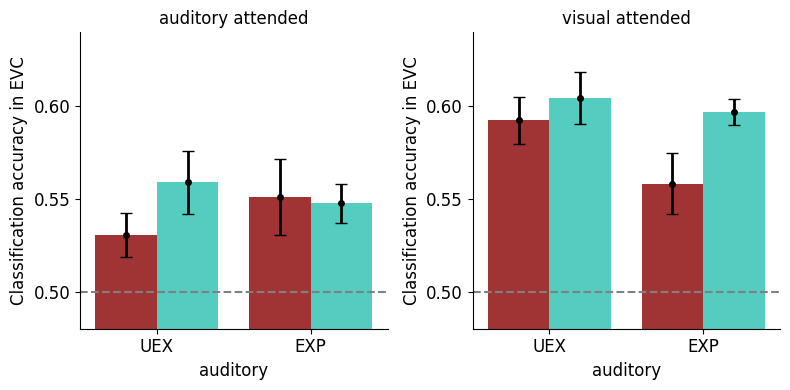

In [63]:
y = "correct"
x = "a_pred"
hue = "v_pred"
id = "subj"
ROI = "EVC"
save_fig = True
ylim = (0.48, 0.64)
yticks = [0.5, 0.55, 0.6]

df_grouped = df.groupby(["subj", "modality", "a_pred", "v_pred"], as_index=False)[y].mean()

anova_df, posthoc_df = analyze_attention_ROI(
    df_grouped, y, x, hue, "visual expected", id, ROI, n_voxels, save_fig, ylim, yticks
)

In [64]:
anova_df

,level_0,level_1,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,auditory attended,0,a_pred,0.000481,1,22,0.000481,0.067711,0.797120,0.797120,0.000699,1.0
1,auditory attended,1,v_pred,0.003578,1,22,0.003578,0.695134,0.413385,0.413385,0.005176,1.0
2,auditory attended,2,a_pred * v_pred,0.005826,1,22,0.005826,1.340331,0.259391,0.259391,0.008400,1.0
3,visual attended,0,a_pred,0.010000,1,22,0.010000,2.075773,0.163736,0.163736,0.015079,1.0
4,visual attended,1,v_pred,0.014901,1,22,0.014901,3.686793,0.067903,0.067903,0.022303,1.0
5,visual attended,2,a_pred * v_pred,0.004078,1,22,0.004078,1.410667,0.247611,0.247611,0.006204,1.0


In [65]:
posthoc_df

,level_0,level_1,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,cohen
0,auditory attended,0,a_pred,-,0,1,True,True,-0.260213,22.0,two-sided,0.797120,NaN,NaN,0.226,-0.062014
1,auditory attended,1,v_pred,-,0,1,True,True,-0.833747,22.0,two-sided,0.413385,NaN,NaN,0.299,-0.177266
2,auditory attended,2,a_pred * v_pred,0,0,1,True,True,-1.525958,22.0,two-sided,0.141269,0.282539,fdr_bh,0.602,-0.309754
3,auditory attended,3,a_pred * v_pred,1,0,1,True,True,0.157194,22.0,two-sided,0.876525,0.876525,fdr_bh,0.221,0.040482
4,visual attended,0,a_pred,-,0,1,True,True,1.440754,22.0,two-sided,0.163736,NaN,NaN,0.542,0.276437
5,visual attended,1,v_pred,-,0,1,True,True,-1.920102,22.0,two-sided,0.067903,NaN,NaN,1.041,-0.343344
6,visual attended,2,a_pred * v_pred,0,0,1,True,True,-0.667679,22.0,two-sided,0.511283,0.511283,fdr_bh,0.268,-0.136130
7,visual attended,3,a_pred * v_pred,1,0,1,True,True,-2.349222,22.0,two-sided,0.028202,0.056403,fdr_bh,2.087,-0.466870


In [66]:
df_grouped.groupby(["modality", "a_pred", "v_pred"])[y].mean().unstack()

v_pred                  0         1
modality a_pred                    
auditory 0       0.530580  0.558967
         1       0.551069  0.547627
visual   0       0.592428  0.604565
         1       0.558261  0.597029

### Multiple comparisons

In [ ]:
import pingouin as pg
import pandas as pd
from statsmodels.stats.multitest import multipletests

results = []
df_visual = df_grouped[df_grouped['modality'] == 'visual']
for a in df_visual['a_pred'].unique():
        subset = df_visual[(df_visual['a_pred'] == a)]
        res = pg.pairwise_tests(dv=y, within='v_pred', subject=id, data=subset,
                                padjust='fdr_bh', effsize='cohen', alternative="less")
        res['a_pred'] = a
        results.append(res)

simple_effects_df = pd.concat(results, ignore_index=True)

# Extract p-values from your combined simple effects dataframe
raw_pvals = simple_effects_df['p-unc']

# Apply FDR correction
reject, pvals_corr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Add corrected results back into the dataframe
simple_effects_df['p-corr'] = pvals_corr
simple_effects_df['significant'] = reject
simple_effects_df

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen,a_pred,p-corr,significant
0,v_pred,0,1,True,True,0.109678,24.0,less,0.543212,0.424,0.018572,0,0.543212,False
1,v_pred,0,1,True,True,-2.320181,24.0,less,0.014577,3.946,-0.402019,1,0.029154,True


In [53]:
results = []
df_auditory = df_grouped[df_grouped['modality'] == 'auditory']
for a in df_auditory['a_pred'].unique():
        subset = df_auditory[(df_auditory['a_pred'] == a)]
        res = pg.pairwise_tests(dv=y, within='v_pred', subject=id, data=subset,
                                padjust='fdr_bh', effsize='cohen', alternative="greater")
        res['a_pred'] = a
        results.append(res)

simple_effects_df = pd.concat(results, ignore_index=True)

# Extract p-values from your combined simple effects dataframe
raw_pvals = simple_effects_df['p-unc']

# Apply FDR correction
reject, pvals_corr, _, _ = multipletests(raw_pvals, alpha=0.05, method='fdr_bh')

# Add corrected results back into the dataframe
simple_effects_df['p-corr'] = pvals_corr
simple_effects_df['significant'] = reject
simple_effects_df

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,cohen,a_pred,p-corr,significant
0,v_pred,0,1,True,True,0.331866,24.0,greater,0.371436,0.443,0.077310,0,0.371436,False
1,v_pred,0,1,True,True,0.926227,24.0,greater,0.181774,0.621,0.188012,1,0.363549,False
